In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv('Heart_disease_statlog.csv')

# SEPARAR ATRIBUTOS PREDITORES
X = df.drop('target', axis=1).values
y = df['target'].values

# AJUSTAR TARGET PARA CLASSIFICAÇÃO BINÁRIA RIGOROSA (0 E 1),
# CONTORNANDO EVENTUAIS PADRÕES STATLOG
if y.max() > 1:
    y = y - y.min()

In [ ]:
# SEPARA 20% DO TOTAL PARA TESTE
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# DOS 80% RESTANTES (X_TEMP), EXTRAÍMOS 25% PARA VALIDAÇÃO
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [ ]:
# PADRONIZAÇÃO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# CONSTRUÇÃO DA TOPOLOGIA DA REDE NEURAL
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu', name='Oculta_1'),
    layers.Dropout(0.2, name='Dropout'),
    layers.Dense(16, activation='relu', name='Oculta_2'),
    layers.Dense(1, activation='sigmoid', name='Saida')
])

# COMPILAÇÃO
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# TREINAMENTO COM CONJUNTO DE VALIDAÇÃO
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5988 - loss: 0.6805 - val_accuracy: 0.5926 - val_loss: 0.6521
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6173 - loss: 0.6513 - val_accuracy: 0.6111 - val_loss: 0.6193
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6296 - loss: 0.6217 - val_accuracy: 0.7037 - val_loss: 0.5891
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.5849 - val_accuracy: 0.7778 - val_loss: 0.5618
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7593 - loss: 0.5655 - val_accuracy: 0.7963 - val_loss: 0.5366
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7160 - loss: 0.5694 - val_accuracy: 0.7963 - val_loss: 0.5156
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7531 - loss: 0.5349 - val_accuracy: 0.7963 - val_loss: 0.4954
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7840 - loss: 0.5162 - val_accuracy: 0.8333 -


DESEMPENHO NO TESTE -> LOSS: 0.6185 | ACURÁCIA: 0.8333


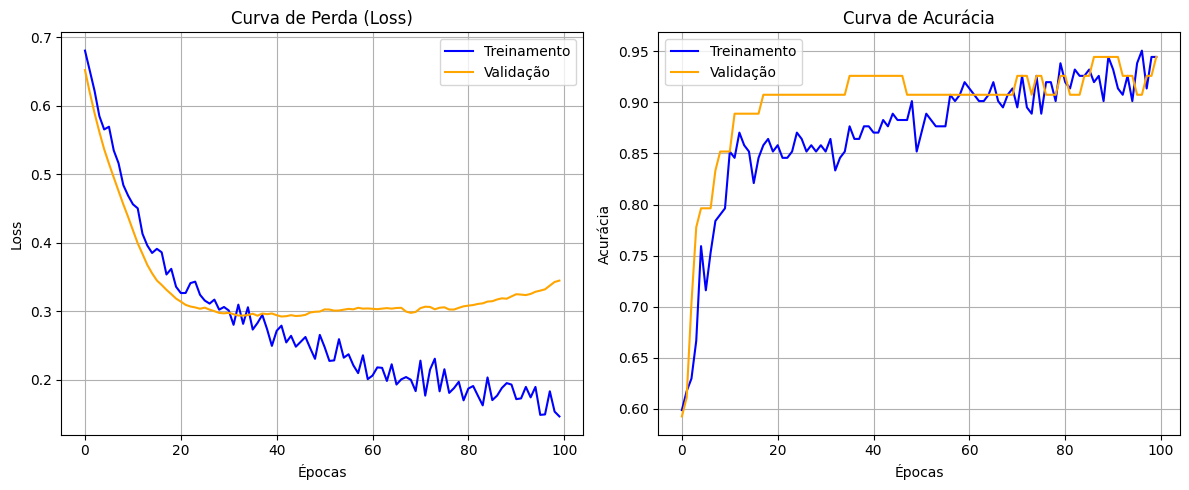

In [ ]:
# AVALIAÇÃO NO CONJUNTO DE TESTE FINAL
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nDESEMPENHO NO TESTE -> LOSS: {test_loss:.4f} | ACURÁCIA: {test_acc:.4f}")

# PLOTANDO AS CURVAS DE AVALIAÇÃO
plt.figure(figsize=(12, 5))

# PLOTAGEM DA CURVA DE PERDA
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento', color='blue')
plt.plot(history.history['val_loss'], label='Validação', color='orange')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# PLOTAGEM DA CURVA DE ACURÁCIA
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento', color='blue')
plt.plot(history.history['val_accuracy'], label='Validação', color='orange')
plt.title('Curva de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()